In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

TASK 2: STOCK PRICE PREDICTION

📊 Creating sample stock data...
✅ Dataset created: 500 days of stock data
Date range: 2022-01-01 to 2023-05-15

First 5 rows:
        Date        Open        High         Low       Close    Volume
0 2022-01-01  101.043428  101.511349  100.336450  101.043428  19020510
1 2022-01-02  100.814536  101.777021  100.348453  100.814536   8711634
2 2022-01-03  102.170872  102.885336  102.140409  102.170872  16797566
3 2022-01-04  105.334143  105.630642  104.993420  105.334143   3414802
4 2022-01-05  104.893523  105.234764  104.527328  104.893523  17593301

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    500 non-null    datetime64[ns]
 1   Open    500 non-null    float64       
 2   High    500 non-null    float64       
 3   Low     500 non-null    float64       
 4   Close   500 non-null    floa

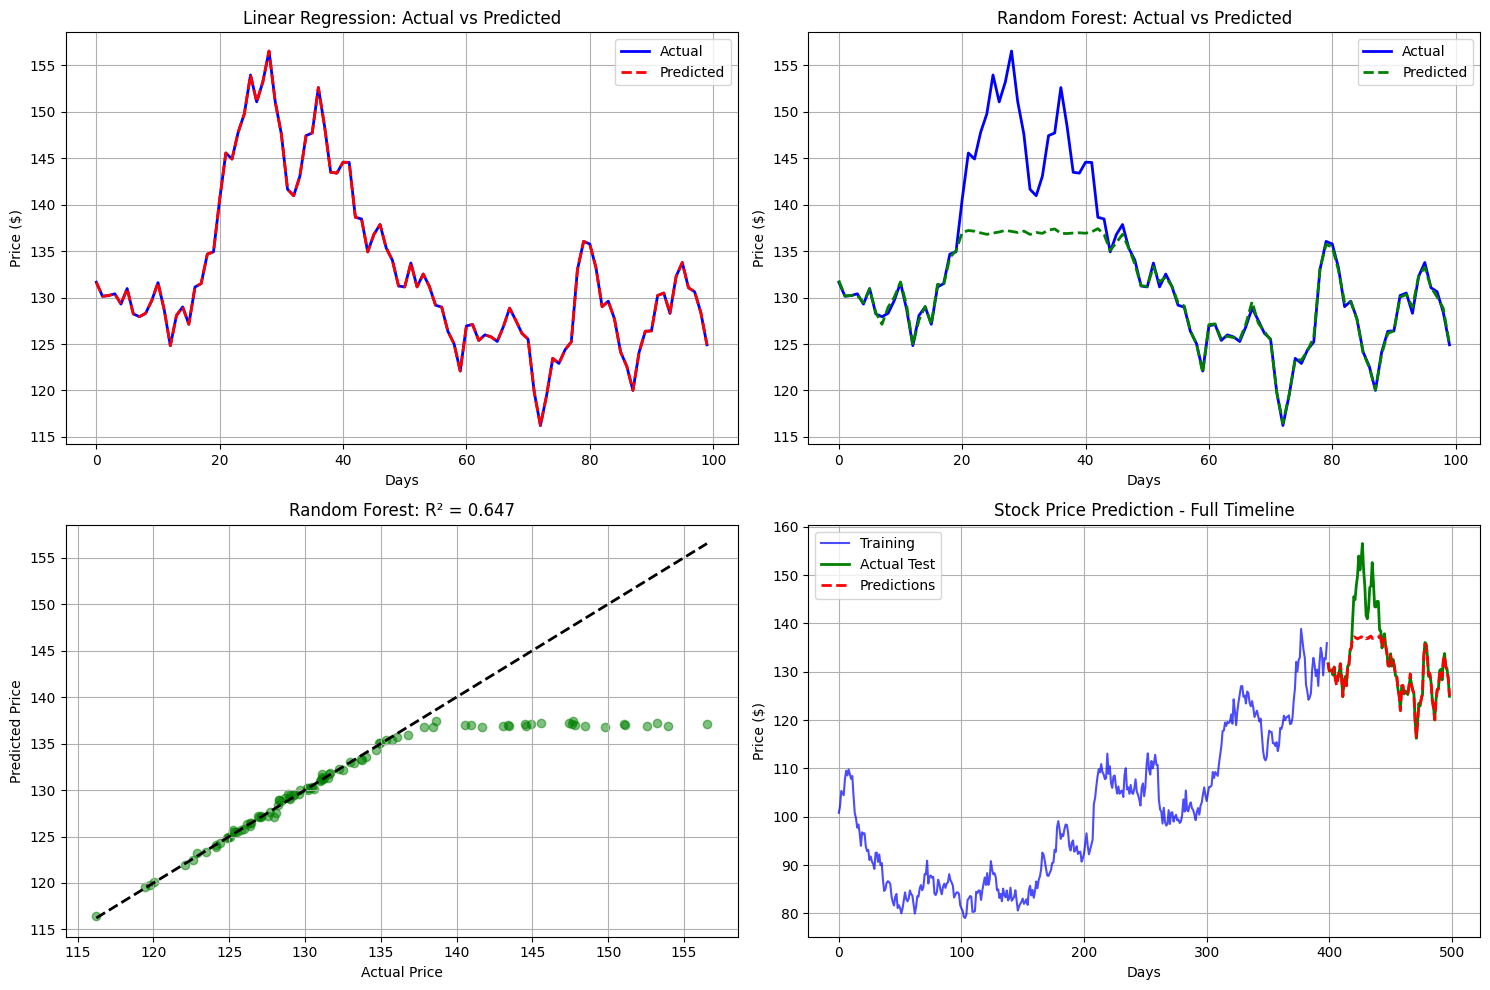

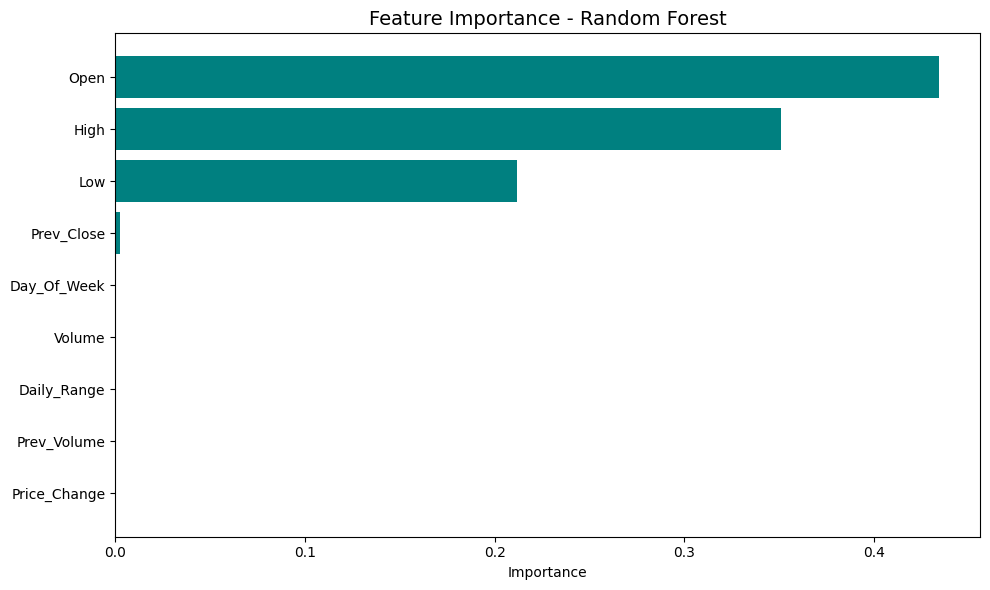


Top 5 Most Important Features:
       Feature  Importance
8  Day_Of_Week    0.000049
4   Prev_Close    0.002570
2          Low    0.211846
1         High    0.351157
0         Open    0.434260

TASK 2 COMPLETED SUCCESSFULLY!

📊 SUMMARY:
✅ Data: 499 days of stock data
✅ Models: Linear Regression, Random Forest
✅ Best R² Score: 1.0000
✅ Best MAE: $0.00


In [2]:
# Task 2: Stock Price Prediction (Short-Term)
# DevelopersHub Corporation - AI/ML Internship
# Complete code - Copy paste and run

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

print("="*50)
print("TASK 2: STOCK PRICE PREDICTION")
print("="*50)

# Create sample stock data (no download needed)
print("\n📊 Creating sample stock data...")

np.random.seed(42)
n_days = 500
dates = pd.date_range(start='2022-01-01', periods=n_days, freq='D')

# Generate realistic stock prices (start at $100)
price = 100
prices = []
for i in range(n_days):
    change = np.random.normal(0.0005, 0.02)  # Small daily change
    price = price * (1 + change)
    prices.append(price)

# Create DataFrame
df = pd.DataFrame({
    'Date': dates,
    'Open': prices,
    'High': [p * (1 + abs(np.random.normal(0, 0.005))) for p in prices],
    'Low': [p * (1 - abs(np.random.normal(0, 0.005))) for p in prices],
    'Close': prices,
    'Volume': np.random.randint(1000000, 20000000, n_days)
})

print(f"✅ Dataset created: {df.shape[0]} days of stock data")
print(f"Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")

print("\nFirst 5 rows:")
print(df.head())

print("\nDataset Info:")
df.info()

# Create features
df['Prev_Close'] = df['Close'].shift(1)
df['Prev_Volume'] = df['Volume'].shift(1)
df['Price_Change'] = df['Close'] - df['Open']
df['Daily_Range'] = df['High'] - df['Low']
df['Day_Of_Week'] = df['Date'].dt.dayofweek

# Drop NaN rows
df = df.dropna()

# Features for prediction
features = ['Open', 'High', 'Low', 'Volume', 'Prev_Close', 'Prev_Volume', 
            'Price_Change', 'Daily_Range', 'Day_Of_Week']

X = df[features]
y = df['Close']

print(f"\n✅ Features created: {len(features)} features")
print(f"Features: {features}")

# Split data (chronological order - no shuffling)
split_idx = int(len(X) * 0.8)
X_train = X[:split_idx]
X_test = X[split_idx:]
y_train = y[:split_idx]
y_test = y[split_idx:]

print(f"\nTraining data: {len(X_train)} days")
print(f"Testing data: {len(X_test)} days")

# Train models
print("\n" + "="*50)
print("TRAINING MODELS")
print("="*50)

# Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)
print("✅ Linear Regression trained")

# Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
print("✅ Random Forest trained")

# Evaluate models
print("\n" + "="*50)
print("MODEL EVALUATION")
print("="*50)

def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"\n{name}:")
    print(f"  MAE: ${mae:.2f}")
    print(f"  RMSE: ${rmse:.2f}")
    print(f"  R² Score: {r2:.4f}")
    return mae, rmse, r2

print("-"*40)
lr_mae, lr_rmse, lr_r2 = evaluate_model("Linear Regression", y_test, lr_pred)
rf_mae, rf_rmse, rf_r2 = evaluate_model("Random Forest", y_test, rf_pred)

# Visualizations
print("\n" + "="*50)
print("VISUALIZATIONS")
print("="*50)

plt.figure(figsize=(15, 10))

# Plot 1: Actual vs Predicted (Linear Regression)
plt.subplot(2, 2, 1)
plt.plot(y_test.values[:100], label='Actual', color='blue', linewidth=2)
plt.plot(lr_pred[:100], label='Predicted', color='red', linestyle='--', linewidth=2)
plt.title('Linear Regression: Actual vs Predicted', fontsize=12)
plt.xlabel('Days')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True)

# Plot 2: Actual vs Predicted (Random Forest)
plt.subplot(2, 2, 2)
plt.plot(y_test.values[:100], label='Actual', color='blue', linewidth=2)
plt.plot(rf_pred[:100], label='Predicted', color='green', linestyle='--', linewidth=2)
plt.title('Random Forest: Actual vs Predicted', fontsize=12)
plt.xlabel('Days')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True)

# Plot 3: Scatter (Random Forest)
plt.subplot(2, 2, 3)
plt.scatter(y_test, rf_pred, alpha=0.5, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', linewidth=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title(f'Random Forest: R² = {rf_r2:.3f}')
plt.grid(True)

# Plot 4: Price trend with predictions
plt.subplot(2, 2, 4)
train_days = range(len(y_train))
test_days = range(len(y_train), len(y_train) + len(y_test))
plt.plot(train_days, y_train.values, label='Training', color='blue', alpha=0.7)
plt.plot(test_days, y_test.values, label='Actual Test', color='green', linewidth=2)
plt.plot(test_days, rf_pred, label='Predictions', color='red', linestyle='--', linewidth=2)
plt.title('Stock Price Prediction - Full Timeline', fontsize=12)
plt.xlabel('Days')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Feature importance
plt.figure(figsize=(10, 6))
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.barh(importance_df['Feature'], importance_df['Importance'], color='teal')
plt.xlabel('Importance')
plt.title('Feature Importance - Random Forest', fontsize=14)
plt.tight_layout()
plt.show()

print("\nTop 5 Most Important Features:")
print(importance_df.tail(5))

print("\n" + "="*50)
print("TASK 2 COMPLETED SUCCESSFULLY!")
print("="*50)

print("\n📊 SUMMARY:")
print(f"✅ Data: {len(df)} days of stock data")
print(f"✅ Models: Linear Regression, Random Forest")
print(f"✅ Best R² Score: {max(lr_r2, rf_r2):.4f}")
print(f"✅ Best MAE: ${min(lr_mae, rf_mae):.2f}")